# Dependancies

In [ ]:
!pip install kagglehub numpy pandas matplotlib seaborn scikit-learn imbalanced-learn

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from imblearn.over_sampling import SMOTE

### Metric Helpers
These are just some metric helpers that we can use of need be

In [ ]:
def compute_metrics(y_true, y_pred, y_prob):
  return{
      "precision": precision_score(y_true, y_pred),
      "recall": recall_score(y_true, y_pred),
      "f1": f1_score(y_true, y_pred),
      "roc_auc": roc_auc_score(y_true, y_prob),
      "mcc": matthews_corrcoef(y_true, y_pred),
  }

def confusion_matrices(splits, Xfeatures, y, train_predict_fn, model_name, file):
    fig, axes = plt.subplots(1, len(splits), figsize=(5 * len(splits), 4))
    if len(splits) == 1:
        axes = [axes]

    for i, (train_idx, test_idx) in enumerate(splits):
        y_pred = train_predict_fn(train_idx, test_idx)
        y_test = y.loc[test_idx]
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                    xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
        axes[i].set_title(f"Split {i + 1}")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")

    fig.suptitle(f"{model_name} - Confusion Matrices", fontweight="bold")
    fig.tight_layout()
    save_fig(fig, file)


def plot_roc_curve(splits, Xfeatures, y, train_predict_proba_fn, model_name, file):
    fig, ax = plt.subplots(figsize=(8, 6))

    for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
        y_prob = train_predict_proba_fn(train_idx, test_idx)
        y_test = y.loc[test_idx]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_val = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"Split {split_num} (AUC = {auc_val:.3f})")

    ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name} ROC Curve")
    ax.legend(loc="lower right")
    fig.tight_layout()
    save_fig(fig, file)


def plot_metrics_bar(results_df, splits, model_name, file):
    fig, ax = plt.subplots(figsize=(10, 5))

    metrics_to_plot = ["precision", "recall", "f1", "roc_auc", "mcc"]
    x = np.arange(len(splits))
    bar_width = 0.15
    colors = ["#056517", "#de1a24", "#3b75e9", "#cad5ed", "#2832c4"]

    for i, metric in enumerate(metrics_to_plot):
        vals = results_df[metric].values
        ax.bar(x + i * bar_width, vals, bar_width, label=metric, color=colors[i])

    ax.set_xlabel("Split", fontsize=12, fontweight="bold")
    ax.set_ylabel("Score", fontsize=12, fontweight="bold")
    ax.set_title(f"{model_name} Metrics", fontsize=14, fontweight="bold")
    ax.set_xticks(x + bar_width * (len(metrics_to_plot) - 1) / 2)
    ax.set_xticklabels([f"Split {i + 1}" for i in range(len(splits))])
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right")
    fig.tight_layout()
    save_fig(fig, file)


def plot_feature_coefficients(coefs, feature_names, model_name, split_label, file, top_n=15):
    fig, ax = plt.subplots(figsize=(12, 6))

    feature_names = np.array(feature_names)
    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    top_idx = sorted_idx[:top_n]

    top_coefs = coefs[top_idx]
    top_names = feature_names[top_idx]
    bar_colors = ["#de1a24" if c < 0 else "#056517" for c in top_coefs]

    ax.barh(top_names, top_coefs, color=bar_colors, edgecolor="black")
    ax.set_xlabel("Coefficient Value", fontsize=12)
    ax.set_title(f"{model_name} - Top {top_n} Coefficients ({split_label})",
                 fontsize=14, fontweight="bold")
    ax.invert_yaxis()
    fig.tight_layout()
    save_fig(fig, file)

# Feed-Forward Neural Network

In [ ]:
class FraudDetectionNN(nn.Module):

  def __init__(self, inputdim, hidden1 = 64, hidden2 = 32, dropout = 0.3):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(inputdim, hidden1),
        nn.BatchNorm1d(hidden1),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(hidden1, hidden2),
        nn.BatchNorm1d(hidden2),
        nn.ReLU(),
        nn.Dropout(dropout),

        nn.Linear(hidden2, 1),
        nn.Sigmoid(),
    )
  def forward(self, x):
    return self.network(x).squeeze(-1)

def _set_seeds():
  torch.manual_seed(42)
  torch.random.seed()
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

def _train_nn(X_train, y_train, inputdim, epochs = 50, batch_size = 128, lr = 1e-3, weight_decay = 1e-4):
  _set_seeds()
  model = FraudDetectionNN(inputdim).to(DEVICE)
  criterion = nn.BCELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay)
  X_arr = X_train.values if hasattr(X_train, "values") else np.array(X_train)
  y_arr = y_train.values if hasattr(y_train, "values") else np.array(y_train)
  X_tensor = torch.FloatTensor(X_arr)
  y_tensor = torch.FloatTensor(y_arr)
  dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
  gen = torch.Generator().manual_seed(42)
  train_loader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True, generator = gen)
  epoch_losses = []
  model.train()
  for epoch in range(50):
    running_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
      optimizer.zero_grad()
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      loss.backward()
      optimizer.step()
      running_loss += loss.item() * len(X_batch)
      n_samples += len(X_batch)
    epoch_loss = running_loss / n_samples
    epoch_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
      print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")
  return model, epoch_losses


def _predict(model, X_test):
  model.eval()
  with torch.no_grad():
    X_arr = X_test.values if hasattr(X_test, "values") else np.array(X_test)
    X_tensor = torch.FloatTensor(X_arr).to(DEVICE)
    y_prob = model(X_tensor).cpu().numpy()
  y_pred = (y_prob>0.5).astype(int)
  return y_pred,y_prob

## Load All Data

In [ ]:
Dataset1 =kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "rupakroy/online-payments-fraud-detection-dataset", "PS_20174392719_1491204439457_log.csv",)

/tmp/ipykernel_10186/1713948650.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  Dataset1 =kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "rupakroy/online-payments-fraud-detection-dataset", "PS_20174392719_1491204439457_log.csv",)


100%|██████████| 178M/178M [00:03<00:00, 54.9MB/s]

Extracting zip of PS_20174392719_1491204439457_log.csv...


In [ ]:
Dataset2 = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "nelgiriyewithana/credit-card-fraud-detection-dataset-2023","creditcard_2023.csv",)

/tmp/ipykernel_40227/2640126912.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  Dataset2 = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "nelgiriyewithana/credit-card-fraud-detection-dataset-2023","creditcard_2023.csv",)


100%|██████████| 143M/143M [00:02<00:00, 68.5MB/s]

Extracting zip of creditcard_2023.csv...


In [ ]:
Dataset3 = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "whenamancodes/fraud-detection", "creditcard.csv",)

/tmp/ipykernel_10186/3503213038.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  Dataset3 = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "whenamancodes/fraud-detection", "creditcard.csv",)


100%|██████████| 66.0M/66.0M [00:00<00:00, 79.9MB/s]

Extracting zip of creditcard.csv...


# Dataset 1

In [ ]:
SAMPLE_SIZE = 100000  # Start with 10,000 rows (adjust as needed: 5000, 10000, 20000)
df1 = Dataset1.sample(n=min(SAMPLE_SIZE, len(Dataset1)), random_state=42)

df1.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


## Preprocessing

In [ ]:
#Cleaning dataset
missing = df1.isnull().sum()
total_missing = missing.sum()
print(f"\nMissing values: {total_missing}")
if total_missing > 0:
    print(missing[missing > 0])

# Check for duplicate rows
duplicates = df1.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")
if duplicates > 0:
    print("  → Dropping duplicates")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"  → New shape: {df.shape[0]:,} rows")

# There are no missing rows or duplicates, therefore null/missing/duplicate cleaning not needed


Missing values: 0
Duplicate rows: 0


In [ ]:
# drop identifiers(nameOrig, nameDest)
df1 = df1.drop(columns=['nameOrig', 'nameDest'])

df1.head()

# encoding "type"
if 'type' in df1.columns:
    print(f"Original 'type' column values: {df1['type'].unique()}")
    print(f"Value counts:\n{df1['type'].value_counts()}")

    label_encoder = LabelEncoder()
    df1['type_encoded'] = label_encoder.fit_transform(df1['type'])
    print(f"\nLabel encoding applied:")
    for i, category in enumerate(label_encoder.classes_):
        print(f"  {category} → {i}")

    df1 = df1.drop(columns=['type'])
    print(f"\nDropped original 'type' column")
else:
    print("No 'type' column found for encoding")

df1.head()

KeyError: "['nameOrig', 'nameDest'] not found in axis"

### Data Analysis

In [ ]:
print(f"Total transactions: {len(Dataset1):,}")
class_counts = Dataset1["isFraud"].value_counts().sort_index()
class_pct = Dataset1["isFraud"].value_counts(normalize=True).sort_index() * 100
print(f"Legitimate transactions: {class_counts[0]:,} ({class_pct[0]:.4f}%)")
print(f"Fraudulent transactions: {class_counts[1]:,} ({class_pct[1]:.4f}%)")

### Feature Engineering

In [ ]:
#Feture Engineering
df1 = df1.assign(
    balance_change_orig=df1['newbalanceOrig'] - df1['oldbalanceOrg']
)

df1 = df1.assign(
    balance_change_dest=df1['newbalanceDest'] - df1['oldbalanceDest']
)

df1 = df1.assign(
    amount_to_balance_ratio=df1['amount'] / (df1['oldbalanceOrg'] + 1)
)

df1 = df1.assign(
    amount_to_dest_ratio=df1['amount'] / (df1['oldbalanceDest'] + 1)
)

df1 = df1.assign(
    abs_balance_change_orig=np.abs(df1['balance_change_orig']),
    abs_balance_change_dest=np.abs(df1.get('balance_change_dest', 0))
)

amount_mean = df1['amount'].mean()
amount_std = df1['amount'].std()

df1 = df1.assign(
    is_large_transaction=(df1['amount'] > amount_mean + 2 * amount_std).astype(int)
)

df1 = df1.assign(
    balance_mismatch_orig=(
        np.abs(df1['newbalanceOrig'] - (df1['oldbalanceOrg'] - df1['amount'])) > 0.01
    ).astype(int)
)

df1 = df1.assign(
    is_zero_balance_after=(df1['newbalanceOrig'] == 0).astype(int)
)

df1 = df1.assign(
    type_amount_interaction=df1['type_encoded'] * np.log1p(df1['amount'])
)

df1 = df1.assign(
    amount_change_interaction=df1['amount'] * df1['balance_change_orig']
)

df1 = df1.assign(
    log_amount=np.log1p(df1['amount']),
    log_oldbalance_orig=np.log1p(df1['oldbalanceOrg']),
    log_oldbalance_dest=np.log1p(df1.get('oldbalanceDest', 0))
)

avg_transaction_amount = df1['amount'].mean()
df1 = df1.assign(
    amount_to_avg_ratio=df1['amount'] / (avg_transaction_amount + 1)
)

df1.head()

## Data Split

In [ ]:
# Features and Targets
X = df1.drop(columns=['isFraud', 'step'])
Y = df1['isFraud']

Y = Y.astype(int)

print(f"Features shape: {X.shape}")
print(f"Target shape: {Y.shape}")
print(f"\nTarget distribution:")
print(f"  Non-Fraud (0): {(Y == 0).sum():,} ({(Y == 0).mean() * 100:.4f}%)")
print(f"  Fraud (1):     {(Y == 1).sum():,} ({(Y == 1).mean() * 100:.4f}%)")


# Data Split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y  # Preserves the fraud ratio in both sets
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"\nTest set: {X_test.shape[0]:,} samples")

In [ ]:
# Handeling scaler applying smote
scaler = RobustScaler() #StandardScaler()

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 3. Handle imbalance with SMOTE (STANDARDIZED approach)
print(f"\nBefore SMOTE - Fraud rate: {(y_train == 1).mean()*100:.4f}%")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE - Fraud rate: {(y_train_resampled == 1).mean()*100:.2f}%")

## Models

### Logistic Regreession

In [ ]:
def _build_lr():
    return LogisticRegression(
        C=1.0,
        solver='saga',  # Supports n_jobs and L1/L2 regularization
        max_iter=1000,
        random_state=42,
        n_jobs=-1,  # Use all CPU cores
        verbose=1   # Set to 1 to see progress
    )


# Train Logistic Regression
lr_model_ds1 = _build_lr()
lr_model_ds1.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred_lr = lr_model_ds1.predict(X_test_scaled)
y_proba_lr = lr_model_ds1.predict_proba(X_test_scaled)[:, 1]


In [ ]:
# Calculate metrics using helper
lr_metrics_ds1 = compute_metrics(y_test, y_pred_lr, y_proba_lr)

print("LOGISTIC REGRESSION PERFORMANCE METRICS\n")
print(f"  Precision: {lr_metrics_ds1['precision']:.4f} ({lr_metrics_ds1['precision']*100:.2f}%)")
print(f"  Recall:    {lr_metrics_ds1['recall']:.4f} ({lr_metrics_ds1['recall']*100:.2f}%)")
print(f"  ROC-AUC:   {lr_metrics_ds1['roc_auc']:.4f}")
print(f"  MCC:       {lr_metrics_ds1['mcc']:.4f}")

In [ ]:
cm_lr_ds1 = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count matrix
sns.heatmap(cm_lr_ds1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Percentage matrix
cm_lr_pct = cm_lr_ds1.astype('float') / cm_lr_ds1.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_lr_pct, annot=True, fmt='.4f', cmap='Reds',
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

# Detailed breakdown
print("="*60)
print("LOGISTIC REGRESSION - CONFUSION MATRIX BREAKDOWN")
print(f"\nTrue Negatives (TN):  {cm_lr_ds1[0,0]:,} - Correctly predicted legitimate")
print(f"False Positives (FP): {cm_lr_ds1[0,1]:,} - Legitimate flagged as fraud")
print(f"False Negatives (FN): {cm_lr_ds1[1,0]:,} - Fraud missed")
print(f"True Positives (TP):  {cm_lr_ds1[1,1]:,} - Correctly detected fraud")

### Random Forest Classifier

In [ ]:
#training random forest model
random_forest_params = {
    'n_estimators': 100,  # T = number of trees
    'max_depth': None,      # Maximum depth of each tree
    'min_samples_split': 2,   # Minimum samples required to split a node
    'min_samples_leaf': 1,    # Minimum samples required at a leaf node
    'max_features': 'sqrt',   # Number of features to consider for best split
    'random_state': 42,
    'n_jobs': -1,         # Use all CPU cores
    # 'class_weight': 'balanced'  # Handle imbalance automatically
}

print("Baseline Random Forest Parameters:")
print(f"  n_estimators: {random_forest_params['n_estimators']}")
print(f"  max_depth: {random_forest_params['max_depth']}")
print(f"  min_samples_split: {random_forest_params['min_samples_split']}")
print(f"  min_samples_leaf: {random_forest_params['min_samples_leaf']}")
print(f"  class_weight: None (no balancing)")
print(f"  random_state: {random_forest_params['random_state']}")

rf_model_ds1 = RandomForestClassifier(**random_forest_params)
rf_model_ds1.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model_ds1.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

#Testing Model
y_pred = rf_model_ds1.predict(X_test_scaled)
y_pred_proba = rf_model_ds1.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

In [ ]:
# Calculate confusion matrix
cm_rf_ds1 = confusion_matrix(y_test, y_pred)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Simple confusion matrix with seaborn
sns.heatmap(cm_rf_ds1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Plot 2: Normalized (percentage) confusion matrix
cm_percentage = cm_rf_ds1.astype('float') / cm_rf_ds1.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percentage, annot=True, fmt='.4f', cmap='Reds',
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

# Print detailed breakdown
print("="*60)
print("CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"\nTrue Negatives (TN):  {cm_rf_ds1[0,0]:,} - Correctly predicted legitimate")
print(f"False Positives (FP): {cm_rf_ds1[0,1]:,} - Legitimate flagged as fraud")
print(f"False Negatives (FN): {cm_rf_ds1[1,0]:,} - Fraud missed")
print(f"True Positives (TP):  {cm_rf_ds1[1,1]:,} - Correctly detected fraud")
print("="*60)

### Feed-Forward Neural Network

In [ ]:
input_dim = X_train_resampled.shape[1]
print(f"Input dimension: {input_dim}")
print(f"Features: {X_train_resampled.columns.tolist()[:5]}...")

scaler = RobustScaler()
numeric_cols = X_train_resampled.select_dtypes(include=[np.number]).columns.tolist()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

model, epoch_losses = _train_nn(
    X_train_resampled,
    y_train_resampled,
    input_dim
)

In [ ]:
# Make predictions
y_pred_nn, y_prob_nn = _predict(model, X_test_scaled)

# Calculate metrics using your helper
nn_metrics = compute_metrics(y_test, y_pred_nn, y_prob_nn)

print("\n" + "="*60)
print("FFNN PERFORMANCE METRICS")
print("="*60)
print(f"  Precision: {nn_metrics['precision']:.4f} ({nn_metrics['precision']*100:.2f}%)")
print(f"  Recall:    {nn_metrics['recall']:.4f} ({nn_metrics['recall']*100:.2f}%)")
print(f"  ROC-AUC:   {nn_metrics['roc_auc']:.4f}")
print(f"  MCC:       {nn_metrics['mcc']:.4f}")

In [ ]:
# Plot training loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, color='#056517', linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title("FFNN Training Loss Over Epochs - Dataset 1", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion Matrix for FFNN
cm_nn = confusion_matrix(y_test, y_pred_nn)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count matrix
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - FFNN', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Percentage matrix
cm_nn_pct = cm_nn.astype('float') / cm_nn.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_nn_pct, annot=True, fmt='.4f', cmap='Reds',
            xticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            yticklabels=['Legitimate (0)', 'Fraudulent (1)'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.show()

# Detailed breakdown
print("="*60)
print("FFNN - CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"\nTrue Negatives (TN):  {cm_nn[0,0]:,} - Correctly predicted legitimate")
print(f"False Positives (FP): {cm_nn[0,1]:,} - Legitimate flagged as fraud")
print(f"False Negatives (FN): {cm_nn[1,0]:,} - Fraud missed")
print(f"True Positives (TP):  {cm_nn[1,1]:,} - Correctly detected fraud")
print("="*60)

#Dataset 2

###Dataset Cleaning

# Dataset 3

### Plan of Action
1. Load Data from kaggle
2. Clean and display information about it
3. Time-based expanding window splits and SMOTE(This is on training data only btw)
4. Logistic Regression - 4 Plots
5. Random Forest
6. FFNN

In [ ]:
RD = "sample_data/results/Dataset3"
os.makedirs(RD, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") #detects whether a GPU is available and tells PyTorch to use it; otherwise it falls back to the CPU.

def save_fig(fig, name):
  path = os.path.join(RD, name)
  fig.savefig(path, dpi = 150, bbox_inches = "tight")
  plt.show()
  plt.close()

## Data Cleaning

In [ ]:
Dataset3["Class"] = Dataset3["Class"].astype(int)
missing = Dataset3.isnull().sum()
total_missing = missing.sum()
if total_missing>0:
  Dataset3 = Dataset3.dropna().reset_index(drop=True)
duplicates = Dataset3.duplicated().sum()
if duplicates>0:
  Dataset3 = Dataset3.drop_duplicates().reset_index(drop=True)


# Data Analysis

## Class Distribution in Bar and Pie Chart

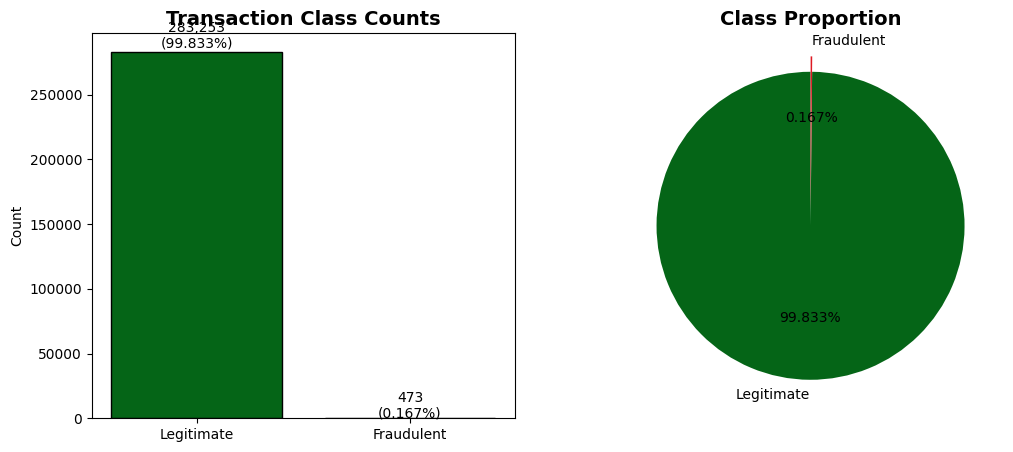

In [ ]:
class_counts = Dataset3["Class"].value_counts().sort_index()
class_pct = Dataset3["Class"].value_counts(normalize=True).sort_index() * 100

colors = ["#056517","#de1a24"]
labels = ["Legitimate", "Fraudulent"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(labels, class_counts.values, color=colors, edgecolor="black")
axes[0].set_title("Transaction Class Counts", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
for i in range(len(labels)):
    count = class_counts.values[i]
    pct   = class_pct.values[i]
    y_position = count + count * 0.01
    label_text = f"{count:,}\n({pct:.3f}%)"
    axes[0].text(i, y_position, label_text, ha="center", fontsize=10)

axes[1].pie(class_counts.values,labels=labels,colors=colors,autopct="%1.3f%%",startangle=90,explode=(0, 0.1),)
axes[1].set_title("Class Proportion", fontsize=14, fontweight = "bold")
save_fig(fig, "Dataset_Class_Distribution")

# All Transactions
These two graphs split up all transactions over time and all fraudulent transactions over the same length of time.

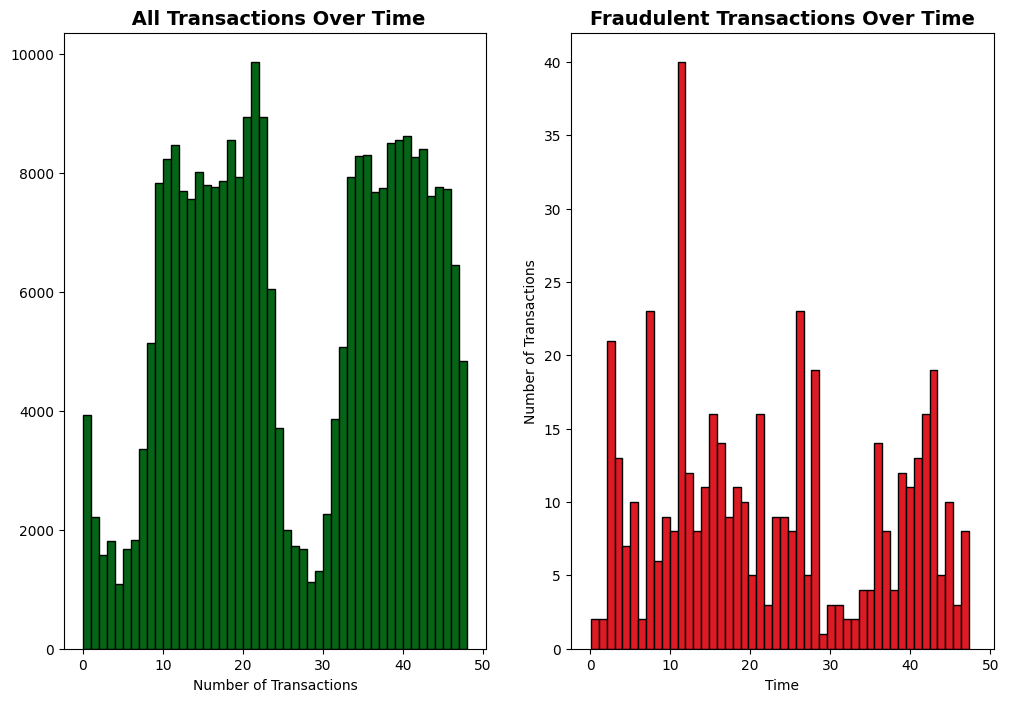

In [ ]:
Dataset3["Hour"] = Dataset3["Time"]/3600
total_hours = Dataset3["Hour"].max()
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex = True) # Sharex
axes[0].hist(Dataset3["Hour"], bins = 48, color = "#056517", edgecolor = "black")
axes[0].set_title(" All Transactions Over Time", fontsize = 14, fontweight = "bold")
axes[0].set_xlabel("Number of Transactions")

fraud_hours = Dataset3[Dataset3["Class"] == 1]["Hour"]
axes[1].hist(fraud_hours, bins = 48, color = "#de1a24", edgecolor = "black")
axes[1].set_title("Fraudulent Transactions Over Time", fontsize = 14, fontweight = "bold")
axes[1].set_ylabel("Number of Transactions")
axes[1].set_xlabel("Time")
save_fig(fig, "All_Transactions_Over_Time")


#Feature Correlation Chart
This cell is measuring which features have the strongest linear correlation with the fraud label and plots it out.

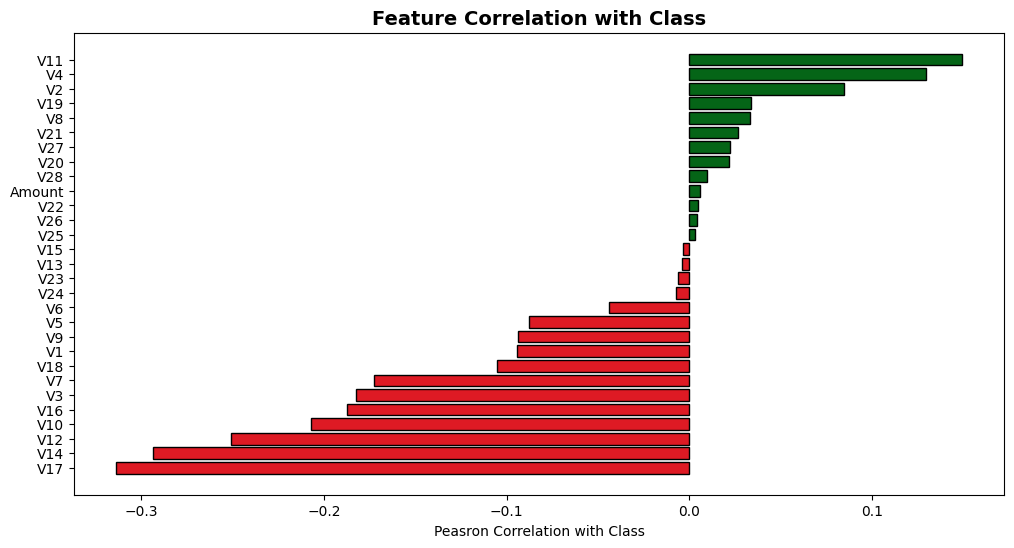

In [ ]:
v_cols = [f"V{i}" for i in range (1,29)]
feature_cols = v_cols + ["Amount"]
corr_class = (Dataset3[feature_cols + ["Class"]].corr()["Class"].drop("Class").sort_values())
fig, ax = plt.subplots(figsize = (12,6))
bar_colors = ["#de1a24" if v<0 else "#056517" for v in corr_class.values]
ax.barh(corr_class.index, corr_class.values, color = bar_colors, edgecolor = "black")
ax.set_xlabel("Peasron Correlation with Class")
ax.set_title("Feature Correlation with Class", fontsize = 14, fontweight = "bold")
save_fig(fig, "Feature_Correlation_Chart")

#Preprocessing and Time Splits

In [ ]:
Dataset3.drop(columns = ["Hour"], inplace=True, errors ="ignore")#inplace
X = Dataset3.drop(columns = ["Class"])
y = Dataset3["Class"]

def create_time_splits(X, test_window = 8, train_hours=16):
  hours = X["Time"]/3600
  total_hours = hours.max()
  splits = []
  test_start = train_hours

  while test_start < total_hours:
    test_end = min(test_start +test_window, total_hours+1)
    train_mask = hours<test_start
    test_mask = (hours>=test_start) & (hours<test_end)
    train_idx = X[train_mask].index.tolist()
    test_idx = X[test_mask].index.tolist()
    if len(train_idx)>0 and len(test_idx) >0:
      splits.append((train_mask, test_mask))

    test_start += test_window
  return splits


def scale_resample(Xfeatures, y, train_idx, test_idx):
  feature_names = Xfeatures.columns.tolist()

  X_trainr = Xfeatures.loc[train_idx]
  X_testr = Xfeatures.loc[test_idx]
  y_trainr = y.loc[train_idx]
  y_testr = y.loc[test_idx]
  scaler = StandardScaler()

  XtrainScaled = pd.DataFrame(scaler.fit_transform(X_trainr), columns= feature_names, index=X_trainr.index)
  XtestScaled = pd.DataFrame(scaler.transform(X_testr), columns = feature_names, index = X_testr.index)

  smote = SMOTE(random_state=42)
  X_train_resampled, y_train_resampled = smote.fit_resample(XtrainScaled, y_trainr)

  return X_train_resampled, y_train_resampled, XtestScaled, y_testr

splits = create_time_splits(X)

# MODELS

## Logistic Regression

In [ ]:
def _build_lr():
  return LogisticRegression(C = 1.0,solver = "lbfgs", max_iter=1000, random_state=42)

Xfeatures = X.drop(columns = ["Time"])
feature_names = Xfeatures.columns.tolist()
lr_results = []
lm = None
for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
  X_train_resampled, y_train_resampled, XtestScaled, y_testr = scale_resample(Xfeatures, y, train_idx, test_idx)
  model = _build_lr()
  model.fit(X_train_resampled, y_train_resampled)
  y_pred = model.predict(XtestScaled)
  y_prob = model.predict_proba(XtestScaled)[:,1]
  metrics = compute_metrics(y_testr, y_pred, y_prob)
  lr_results.append(metrics)
lm = model
lr_results = pd.DataFrame(lr_results)

### Visualizations

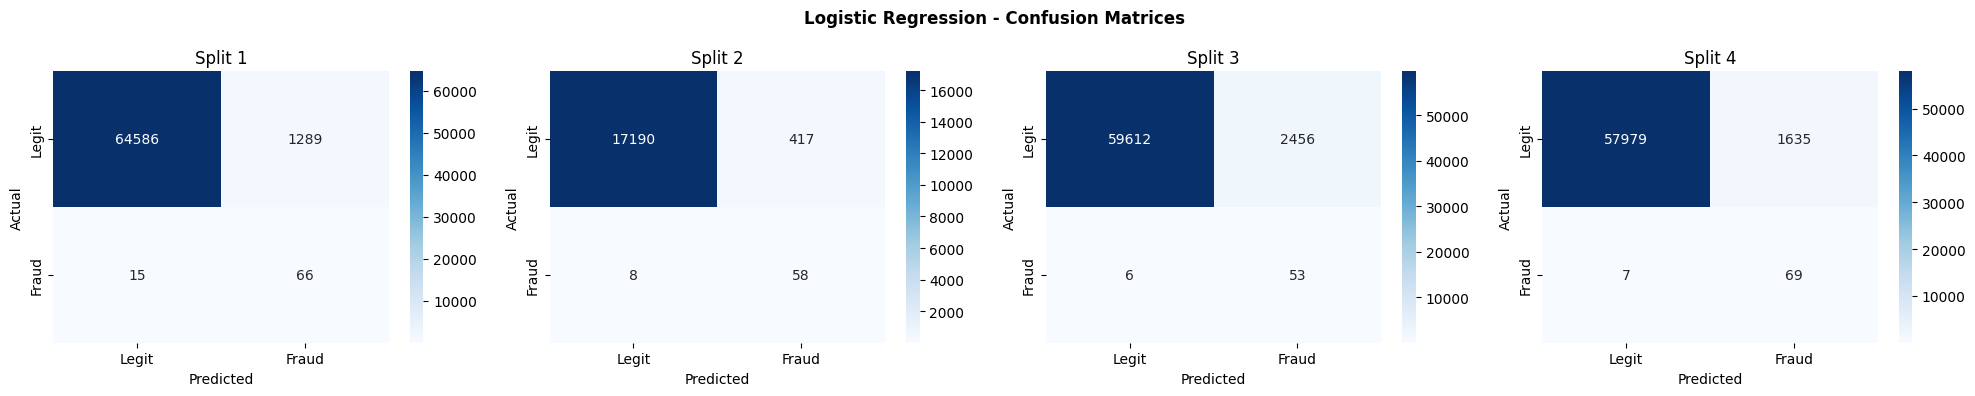

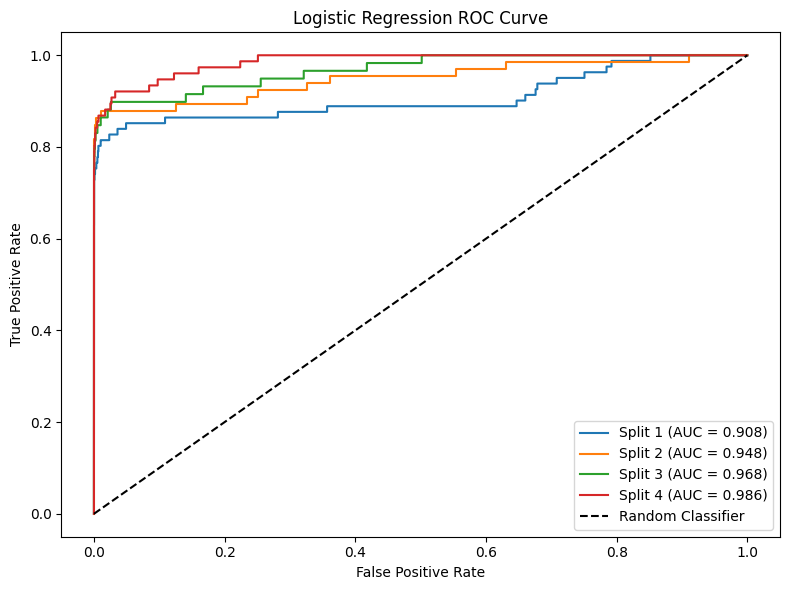

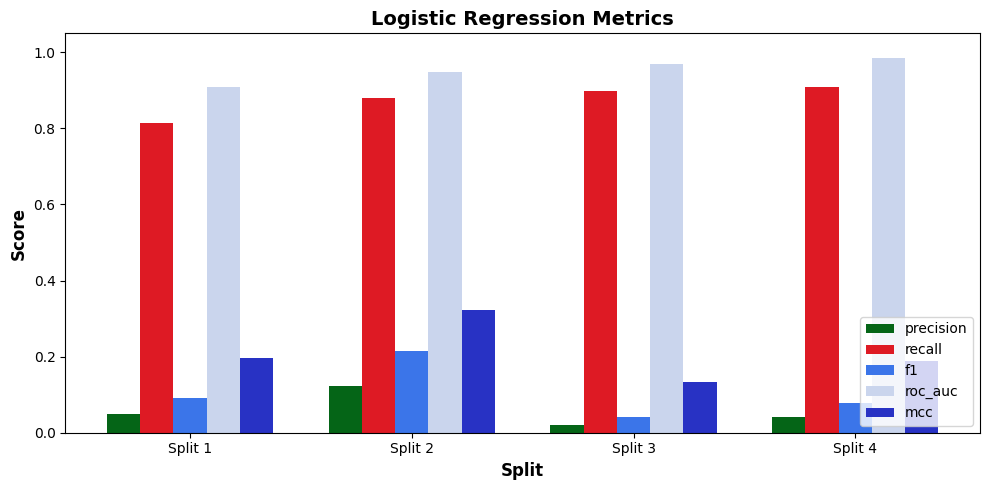

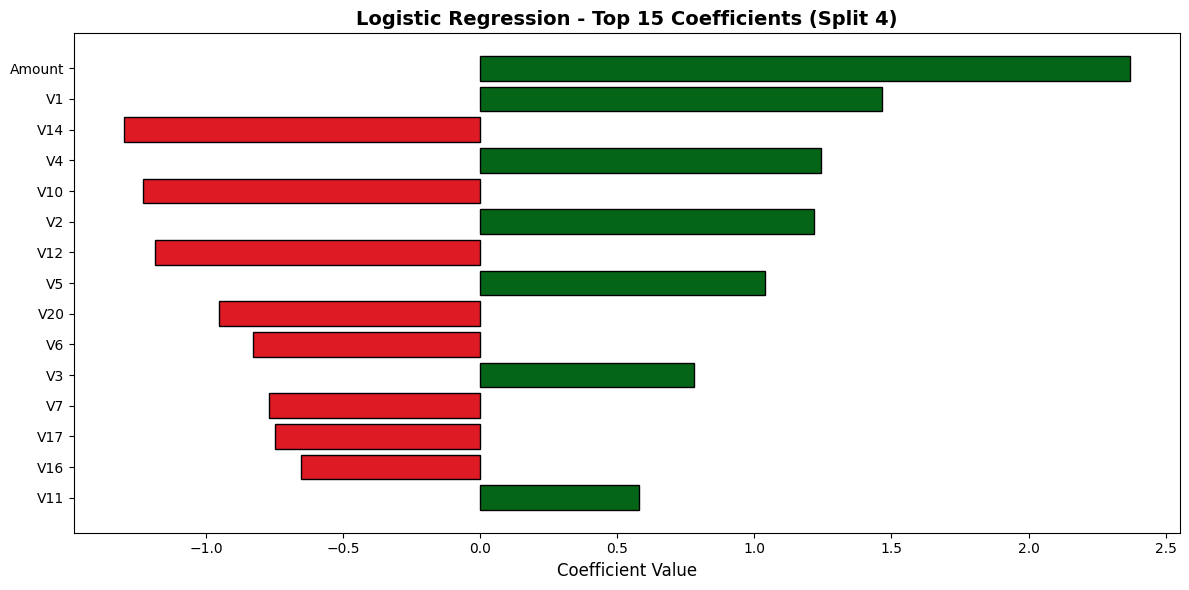

In [ ]:
def _lr_train_predict(train_idx, test_idx):
    X_tr, y_tr, X_te, _, = scale_resample(Xfeatures, y, train_idx, test_idx)
    model = _build_lr()
    model.fit(X_tr, y_tr)
    return model.predict(X_te)

def _lr_train_predict_proba(train_idx, test_idx):
    X_tr, y_tr, X_te, _, = scale_resample(Xfeatures, y, train_idx, test_idx)
    model = _build_lr()
    model.fit(X_tr, y_tr)
    return model.predict_proba(X_te)[:, 1]

confusion_matrices(splits, Xfeatures, y, _lr_train_predict, "Logistic Regression", "Logistic_Regression_Confusion_Matrix")
plot_roc_curve(splits, Xfeatures, y, _lr_train_predict_proba,"Logistic Regression", "Logistic_Regression_ROC_Curve")
plot_metrics_bar(pd.DataFrame(lr_results), splits,"Logistic Regression", "Logistic_Regression_Metrics")
plot_feature_coefficients(lm.coef_[0], feature_names,"Logistic Regression", f"Split {len(splits)}", "Datadet3_LR_feature_coefficients.png")

# Random Forest
TO DO

In [ ]:
def _build_rf():
  return RandomForestClassifier(
      n_estimators=100,
      max_depth=None,
      min_samples_split=2,
      min_samples_leaf=1,
      max_features="sqrt",
      random_state=42,
      n_jobs= -1
  )

rf_results = []
rf_last_model = None

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
  X_train_resampled, y_train_resampled, XtestScaled, y_testr = scale_resample(Xfeatures, y, train_idx, test_idx)
  model = _build_rf()
  model.fit(X_train_resampled, y_train_resampled)
  y_pred = model.predict(XtestScaled)
  y_prob = model.predict_proba(XtestScaled)[:, 1]
  metrics = compute_metrics(y_testr, y_pred, y_prob)
  metrics["split"] = split_num
  rf_results.append(metrics)
  rf_last_model = model

rf_df = pd.DataFrame(rf_results)

### Visualizations

In [ ]:
def _rf_train_predict(train_idx, test_idx):
  X_tr, y_tr, X_te, _ = scale_resample(Xfeatures, y, train_idx, test_idx)
  m = _build_rf()
  m.fit(X_tr, y_tr)
  return m.predict(X_te)

def _rf_train_predict_proba(train_idx, test_idx):
  X_tr, y_tr, X_te, _ = scale_resample(Xfeatures, y, train_idx, test_idx)
  m = _build_rf()
  m.fit(X_tr, y_tr)
  return m.predict_proba(X_te)[:, 1]

confusion_matrices(splits, Xfeatures, y, _rf_train_predict, "Random Forest", "RandomForestConfusionMatrices.png")
plot_roc_curve(splits, Xfeatures, y, _rf_train_predict_proba, "Random Forest", "RandomForestROC.png")
plot_metrics_bar(rf_df, splits, "Random Forest", "RandomForestMetrics.png")

importances = rf_last_model.feature_importances_
top_n = 15
sorted_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(top_n), importances[sorted_idx], color=["#de1a24" if i < 0 else "#056517" for i in importances[sorted_idx]], edgecolor="black")
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importances", fontsize=14, fontweight="bold")
fig.tight_layout()
save_fig(fig, "RandomForestFeatureImportances.png")

## FFNN Training, Evaluations and Visuals

Epoch [1/50], Loss: 0.0927
Epoch [10/50], Loss: 0.0192
Epoch [20/50], Loss: 0.0161
Epoch [30/50], Loss: 0.0160
Epoch [40/50], Loss: 0.0160
Epoch [50/50], Loss: 0.0154


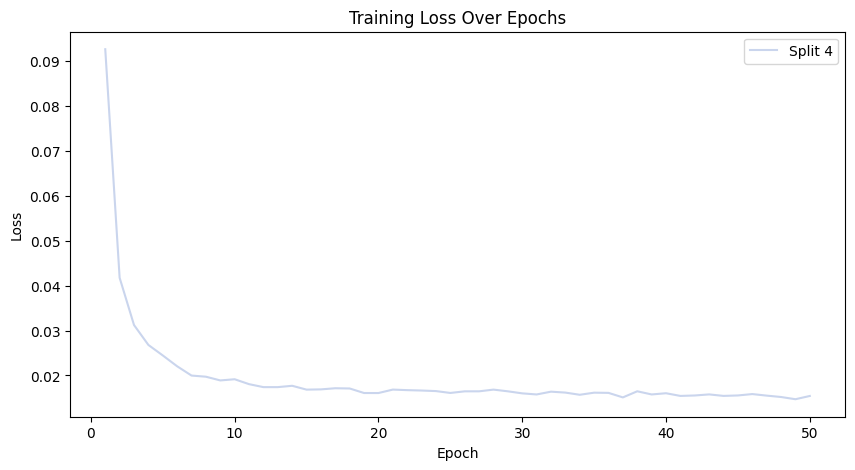

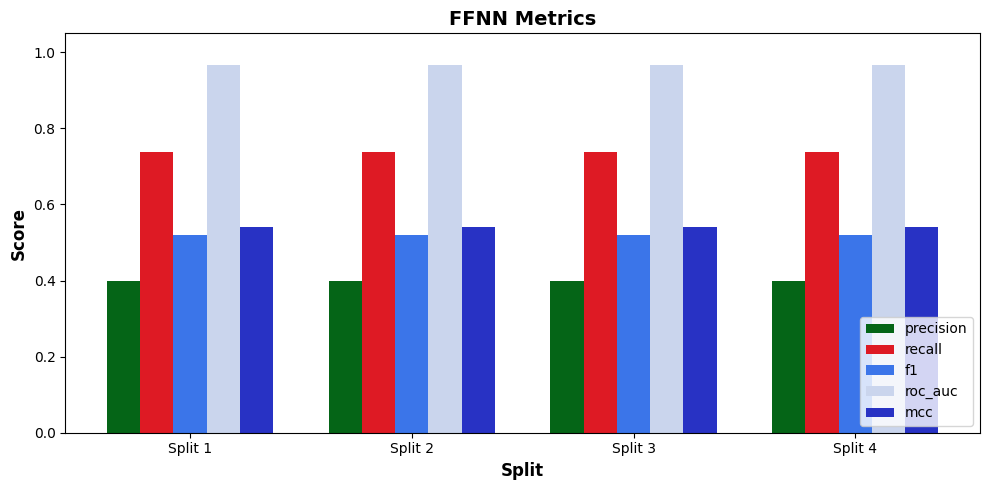

KeyError: 1

In [ ]:
input_dim = Xfeatures.shape[1]
nn_results = []
split_predictions = {}
all_epoch_losses = {}

for split_num, (train_idx, test_idx) in enumerate(splits, start=1):
  X_train_resampled, y_train_resampled, XtestScaled, y_testr = scale_resample(Xfeatures, y, train_idx, test_idx)

  model, epoch_losses = _train_nn(X_train_resampled, y_train_resampled, input_dim)
  y_pred, y_prob = _predict(model, XtestScaled)
  metrics = compute_metrics(y_testr, y_pred, y_prob)
  metrics["split"] = split_num
  nn_results.append(metrics)
  split_predictions[split_num] = {"y_pred": y_pred, "y_prob": y_prob}
  all_epoch_losses[split_num] = epoch_losses

nn_results = pd.DataFrame(nn_results)

fig, ax = plt.subplots(figsize=(10,5))
color_splits = ["#056517", "#de1a24", "#3b75e9", "#cad5ed"]
for split_num in sorted(all_epoch_losses.keys()):
  losses = all_epoch_losses[split_num]
  color = color_splits[(split_num-1)%len(color_splits)]
  ax.plot(range(1, len(losses) +1), losses, label=f"Split {split_num}", color=color)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Over Epochs")
ax.legend()
save_fig(fig, "Training_Loss.png")

def make_predictor(key):
  predictions = [split_predictions[i+1][key] for i in range(len(splits))]
  call_idx = [0]

  def predictor(train_idx, test_idx):
    result = predictions[call_idx[0]]
    call_idx[0] += 1
    return result
  return predictor

plot_metrics_bar(nn_results,splits, "FFNN", "FFNN_Metrics")
plot_roc_curve(splits, Xfeatures, y, make_predictor("y_prob"), "FFNN", "FFNN_ROC_Curve")
confusion_matrices(splits, Xfeatures, y, make_predictor("y_pred"), "FFNN", "FFNN_Confusion_Matrix")

# Comparison